In [1]:
try:
    import xgboost as xgb
except:
    !uv pip install xgboost
    import xgboost as xgb

xgb.__version__

'3.2.0'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


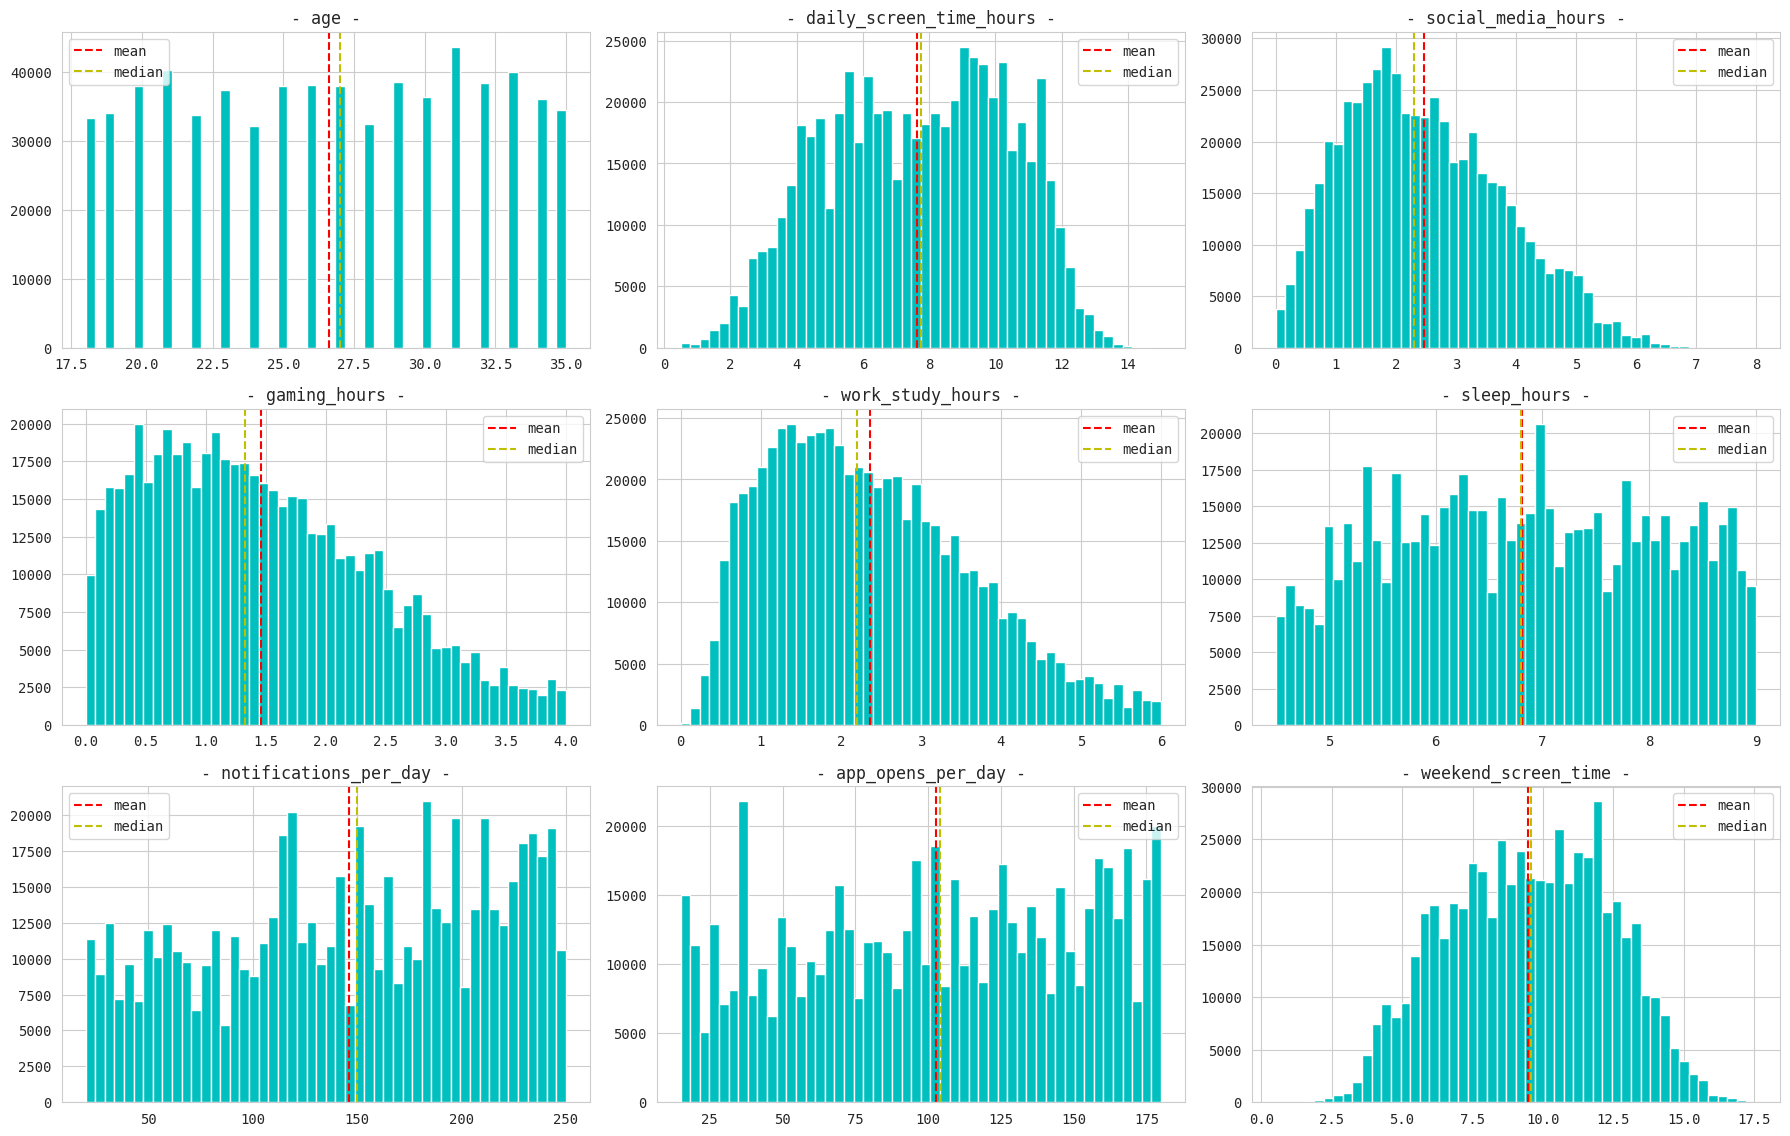

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Original,Test
age,18,18,18
daily_screen_time_hours,1389,900,1349
social_media_hours,721,551,703
gaming_hours,401,401,401
work_study_hours,600,551,601
sleep_hours,451,451,451
notifications_per_day,231,231,231
app_opens_per_day,166,166,166
weekend_screen_time,1437,1096,1404
gender,3,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end='')
# for col in NUMS: # 'Position_Change'
#     freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test]: # , orig
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
# train[FREQ_COLS]

In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic features --

# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=["mean", "count", "std"], # mean, median, "count", "std", skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [24]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     # orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize -- 
#     combined  = pd.concat([train[n], test[n]]) # , orig[n]
#     cat_v = combined.factorize()[0]
#     cat_v = pd.Series(cat_v).astype('category')
#     train[n] = cat_v[:len(train)].astype('int32')
#     test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
#     # orig[n]  = __[len(train)+len(test):].astype('int32')

# del combined, cat_v
# print(f"Nums to Cats: {len(CATS_2)}")

# CATS_2

In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])

## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in NUMS:
#     n = f"cat_{c}"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
## ------------------------------------------------------------

## -- Factorize all CATS data --
for c in CATS:
    combined[c] = combined[c].factorize()[0]
    combined[c] = combined[c].astype('category')
    
train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 12
Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,1.0


# ML TRAINING

In [26]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
              use_orig=False, early_stop=100, print_every=200):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits} | {get_system_info()}", end=" | ")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
                fill_nan=True,
            )

        # te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)
    
        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].factorize()[0]
        #     combined[c] = combined[c].astype('category')
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape}")

        # -------------------------------------------------------------------------------
        # dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
        # dval   = xgb.DMatrix(X_valid, y_valid, enable_categorical=True)
        # dtest  = xgb.DMatrix(X_test, enable_categorical=True)
        # model = xgb.train( 
        #     params,
        #     dtrain,
        #     num_boost_round=15_000,
        #     evals=[(dtrain, 'train'), (dval, 'valid')],
        #     early_stopping_rounds=early_stop,
        #     verbose_eval=print_every,
        # )
        # ## -- Predictions --
        # oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration+1))
        # test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration+1)) / kfold.n_splits
        # -------------------------------------------------------------------------------
        model = xgb.XGBClassifier(**params, early_stopping_rounds=early_stop)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid), (X_valid, y_valid)], verbose=print_every)

        ## -- Predictions --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- Clean up memory --
        # del dtrain, dval, dtest
        # gc.collect()

    # ## -- Average the test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Calculate out-of-fold Score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'score': oof_score,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'model': model,
        'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [27]:
## -- Plot Feature Importances --
def plot_feature_importances(num_models=1, max_cols=10):
    for i, (k, v) in enumerate(all_predictions.items()):
        for j, (x, y) in enumerate(v.items()):
            if x == 'model':
                display_limit = 20
                if max_cols > display_limit:
                    print('⚠️ Display limit is 20 features')

                _, axs = plt.subplots(1, 2, figsize=(16, min(20, max_cols)*0.35))

                ## -- Feature Gain --
                xgb.plot_importance(y, importance_type='gain', max_num_features=max_cols,
                                    ax=axs[0], height=0.5, show_values=False,)
                axs[0].set_title('Average gain of splits which use the feature')
                axs[0].set_ylabel('Feature_id', fontdict={'size': 12, 'weight': 'bold'})

                ## -- Feature Weight --
                xgb.plot_importance(y, importance_type='weight', max_num_features=max_cols,
                                    ax=axs[1], height=0.5, show_values=False,)
                axs[1].set_title('Number of times a feature appears in a tree')
                axs[1].set_ylabel('')

                for ax in axs:
                    ax.set_xlabel('Importance', fontdict={'size': 12, 'weight': 'bold'})
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)

                plt.suptitle(f"{k}_{str(all_scores[k]).split('.')[1]}", fontsize=20, fontweight='bold')
                plt.tight_layout()
                plt.show()
                print()

print("📊 Feature Importance plot function ready!")

📊 Feature Importance plot function ready!


In [28]:
VER = f"xgb_orig{48}_" # {test.shape[1]}
all_predictions = {}

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = CATS # + CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,1.0


#### Summary (Order) Checklist
---
1) **GBDT & GRADIENT**
* [Pair 1: Model Complexity] -> (`max_depth` + `min_child_weight`)
* [Pair 2: Randomization]    -> (`subsample` + `colsample_bytree`)
* [Single: Regularization]   -> (`alpha` / `lambda` / `gamma`)
* [Single: Final Polish]     -> (`Lower` `learning_rate`)
---
2) **LOSSGUIDE**
* [Pair 1: Leaf Complexity] -> (`max_leaves` + `max_depth`)
* [Single: Regularization]  -> (`min_child_weight`)
* [Pair 2: Randomization]   -> (`subsample` + `colsample_bytree`)
* [Single: Regularization]  -> (`alpha` / `lambda` / `gamma`)
* [Single: Final Polish]    -> (`Lower` `learning_rate`)

In [29]:
# ## ===== PARAMETER ADJUSTMENT TRAINER =====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_predictions:
# #     all_predictions.clear()

# OUT_LOOP = [1, 3, 5, 10]
# INN_LOOP = [0]
# p_name   = ['sub', 'col']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         trial_params = {
#             # "sampling_method": "gradient_based",
#             # # ----------------------------------
#             # "grow_policy": "lossguide",
#             # "max_leaves": outer,
#             # "max_depth": 0, # 0 if lossguide
#             # ------------------------------------
#             "objective": "binary:logistic",
#             "eval_metric": "auc",
#             "enable_categorical": True,
#             "n_estimators": 15_000,
#             # "learning_rate": outer,
#             # "subsample": outer,
#             # "colsample_bytree": inner,
#             # "reg_alpha": 10.0,
#             # "reg_lambda": 5.0,
#             "min_child_weight": outer,
#             # "max_bins": 780,
#             # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
#             "random_state": CFG['SEED'],
#             "verbosity": 0,
#             "n_jobs": -1,
#             "device": "cuda" if torch.cuda.is_available() else "cpu",
#         }

#         n = "_" + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}_"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=trial_params,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             use_orig=True,
#             # early_stop=100,
#             # print_every=500,
#         )

# print(f"\n===== ☑️ Complete! {len(all_predictions)} model(s) =====\n")

In [30]:
# ==================================================
# 5-FOLD CV: gbdt_TE_original_INNER_FOLD
# ==================================================
#  • Fold 1 AUC: 0.963651
#  • Fold 2 AUC: 0.964406
#  • Fold 3 AUC: 0.964479
#  • Fold 4 AUC: 0.964780
#  • Fold 5 AUC: 0.963857
# -------------------------------------------------|
# Overall AUC: 0.96423
# Average AUC: 0.964235 ± 0.000417
# -------------------------------------------------|
# 5.16 mins

# ==================================================
# 5-FOLD CV: gbdt_TE_original_OUTSIDE
# ==================================================
#  • Fold 1 AUC: 0.963308
#  • Fold 2 AUC: 0.964047
#  • Fold 3 AUC: 0.964060
#  • Fold 4 AUC: 0.964502
#  • Fold 5 AUC: 0.963752
# -------------------------------------------------|
# Overall AUC: 0.96393
# Average AUC: 0.963934 ± 0.000394
# -------------------------------------------------|
# 4.28 mins

# ==================================================
# 5-FOLD CV: gbdt_base
# ==================================================
#  • Fold 1 AUC: 0.962443
#  • Fold 2 AUC: 0.963041
#  • Fold 3 AUC: 0.963290
#  • Fold 4 AUC: 0.963754
#  • Fold 5 AUC: 0.962605
# -------------------------------------------------|
# Overall AUC: 0.963021
# Average AUC: 0.963027 ± 0.000473
# -------------------------------------------------|
# 3.64 mins

In [31]:
# ================================================== 
# 5-FOLD CV: BOOST - (553096, 48)
# + ORIGINAL FEATURES
# sub=0.95, col=0.8, depth=_, child=35, l1=10.0, l2=5.0, lr=_
# ==================================================
#  • Fold 1 AUC: 0.963991
#  • Fold 2 AUC: 0.964624
#  • Fold 3 AUC: 0.964573
#  • Fold 4 AUC: 0.964968
#  • Fold 5 AUC: 0.964044
# -------------------------------------------------|
# Overall AUC: 0.964435
# Average AUC: 0.964440 ± 0.000371
# -------------------------------------------------|
# 6.05 mins

In [32]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "score":
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot([*all_scores.values()], marker="s")

# y_add = 1e-6

# for i, s1 in enumerate([*all_scores.values()]):
#     ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# # plt.ylim((0.94, 0.955))
# plt.legend(loc="best")
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title("XGBoost scores", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout() 
# plt.show()

In [33]:
# ## -- Plot feature importances --
# plot_feature_importances(num_models=1, max_cols=20)

In [34]:
LR = 0.03
# L2_REG = 2.5
EARLY_STOP   = 200
PRINT_STEPS  = 1000
USE_ORIGINAL = True

In [35]:
## ============ BOOSTING
# FE (84): sub=0.95, col=0.4, depth=_, child=3, l1=15, l2=12, lr=0.02
# Orig (48): sub=0.95, col=0.8, depth=_, child=35, l1=10, l2=5, lr=_

gbt_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    "enable_categorical": True,
    "n_estimators": 15_000,
    'learning_rate': LR,
    # 'max_depth': 8,
    # 'subsample': 0.8,
    # 'colsample_bytree': 0.8,
    # 'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    # "gamma": 0.1,
    'min_child_weight': 40,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = VER + "gbdt"

# for VALUE in MULTI_SEEDS:
#     PARAMS['random_state'] = gb_seed
#     n = n #+ str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=gbt_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: xgb_orig48_gbdt =====
Using REGULAR splits --- 

##### FOLD 1/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93388	validation_1-auc:0.93388
[1000]	validation_0-auc:0.96277	validation_1-auc:0.96277
[2000]	validation_0-auc:0.96449	validation_1-auc:0.96449
[3000]	validation_0-auc:0.96512	validation_1-auc:0.96512
[4000]	validation_0-auc:0.96525	validation_1-auc:0.96525
[4010]	validation_0-auc:0.96525	validation_1-auc:0.96525
 • Fold 1 AUC: 0.965258

##### FOLD 2/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93391	validation_1-auc:0.93391
[1000]	validation_0-auc:0.96318	validation_1-auc:0.96318
[2000]	validation_0-auc:0.96519	validation_1-auc:0.96519
[3000]	validation_0-auc:0.96576	validation_1-auc:0.96576
[4000]	validation_0-auc:0.96604	validation_1-auc:0.96604
[4970]	validation_0-auc:0.96611	validation_1-auc:0.96611
 • Fold 2 AUC: 0.966116

##### FOLD 3/5 | CPU: 4 | 

...

Train shape: (553095, 48)
[0]	validation_0-auc:0.93436	validation_1-auc:0.93436
[1000]	validation_0-auc:0.96325	validation_1-auc:0.96325
[2000]	validation_0-auc:0.96519	validation_1-auc:0.96519
[3000]	validation_0-auc:0.96571	validation_1-auc:0.96571
[4000]	validation_0-auc:0.96586	validation_1-auc:0.96586
[5000]	validation_0-auc:0.96595	validation_1-auc:0.96595
[5308]	validation_0-auc:0.96595	validation_1-auc:0.96595
 • Fold 3 AUC: 0.965961

##### FOLD 4/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93517	validation_1-auc:0.93517
[1000]	validation_0-auc:0.96371	validation_1-auc:0.96371
[2000]	validation_0-auc:0.96564	validation_1-auc:0.96564
[3000]	validation_0-auc:0.96614	validation_1-auc:0.96614
[4000]	validation_0-auc:0.96631	validation_1-auc:0.96631
[4678]	validation_0-auc:0.96634	validation_1-auc:0.96634
 • Fold 4 AUC: 0.966357

##### FOLD 5/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553096, 48)
[0]	validation_0-auc:0.93328	validation_1-auc:0.93328
[1000]	validation_0-auc:0.96252	validation_1-auc:0.96252
[2000]	validation_0-auc:0.96466	validation_1-auc:0.96466
[3000]	validation_0-auc:0.96528	validation_1-auc:0.96528
[4000]	validation_0-auc:0.96548	validation_1-auc:0.96548
[4938]	validation_0-auc:0.96553	validation_1-auc:0.96553
 • Fold 5 AUC: 0.965535

5-FOLD CV: xgb_orig48_gbdt
 • Fold 1 AUC: 0.965258
 • Fold 2 AUC: 0.966116
 • Fold 3 AUC: 0.965961
 • Fold 4 AUC: 0.966357
 • Fold 5 AUC: 0.965535
-------------------------------------------------|
Overall AUC: 0.965845
Average AUC: 0.965845 ± 0.000398
-------------------------------------------------|
82.86 mins



In [36]:
## =================== LOSS GUIDE
# FE (84): sub=0.95, col=0.4, child=40, max_leaves=32, l1=10, l2=4, lr=0.02

loss_params = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': 32,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    "enable_categorical": True,
    "n_estimators": 15_000,
    'learning_rate': LR,
    # 'subsample': 0.8,
    # 'colsample_bytree': 0.6,
    # 'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    # "gamma": 0.1,
    'min_child_weight': 80,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = VER + "loss"

# for VALUE in MULTI_SEEDS:
#     PARAMS['random_state'] = VALUE
#     n = n #+ str(l_seed)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: xgb_orig48_loss =====
Using REGULAR splits --- 

##### FOLD 1/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.92717	validation_1-auc:0.92717
[1000]	validation_0-auc:0.96313	validation_1-auc:0.96313
[2000]	validation_0-auc:0.96439	validation_1-auc:0.96439
[3000]	validation_0-auc:0.96478	validation_1-auc:0.96478
[4000]	validation_0-auc:0.96500	validation_1-auc:0.96500
[5000]	validation_0-auc:0.96505	validation_1-auc:0.96505
[5155]	validation_0-auc:0.96505	validation_1-auc:0.96505
 • Fold 1 AUC: 0.965053

##### FOLD 2/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.92690	validation_1-auc:0.92690
[1000]	validation_0-auc:0.96380	validation_1-auc:0.96380
[2000]	validation_0-auc:0.96510	validation_1-auc:0.96510
[3000]	validation_0-auc:0.96554	validation_1-auc:0.96554
[4000]	validation_0-auc:0.96571	validation_1-auc:0.96571
[4038]	validation_0-auc:0.96572	validation_1-auc:0.96572
 • Fold 2 AUC: 0.965723

##### FOLD 3/5 | CPU: 4 | 

...

Train shape: (553095, 48)
[0]	validation_0-auc:0.92832	validation_1-auc:0.92832
[1000]	validation_0-auc:0.96387	validation_1-auc:0.96387
[2000]	validation_0-auc:0.96520	validation_1-auc:0.96520
[3000]	validation_0-auc:0.96562	validation_1-auc:0.96562
[4000]	validation_0-auc:0.96579	validation_1-auc:0.96579
[5000]	validation_0-auc:0.96588	validation_1-auc:0.96588
[5426]	validation_0-auc:0.96588	validation_1-auc:0.96588
 • Fold 3 AUC: 0.965888

##### FOLD 4/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.92782	validation_1-auc:0.92782
[1000]	validation_0-auc:0.96437	validation_1-auc:0.96437
[2000]	validation_0-auc:0.96556	validation_1-auc:0.96556
[3000]	validation_0-auc:0.96603	validation_1-auc:0.96603
[4000]	validation_0-auc:0.96616	validation_1-auc:0.96616
[4959]	validation_0-auc:0.96623	validation_1-auc:0.96623
 • Fold 4 AUC: 0.966230

##### FOLD 5/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553096, 48)
[0]	validation_0-auc:0.92698	validation_1-auc:0.92698
[1000]	validation_0-auc:0.96339	validation_1-auc:0.96339
[2000]	validation_0-auc:0.96473	validation_1-auc:0.96473
[3000]	validation_0-auc:0.96519	validation_1-auc:0.96519
[4000]	validation_0-auc:0.96537	validation_1-auc:0.96537
[5000]	validation_0-auc:0.96548	validation_1-auc:0.96548
[5559]	validation_0-auc:0.96549	validation_1-auc:0.96549
 • Fold 5 AUC: 0.965498

5-FOLD CV: xgb_orig48_loss
 • Fold 1 AUC: 0.965053
 • Fold 2 AUC: 0.965723
 • Fold 3 AUC: 0.965888
 • Fold 4 AUC: 0.966230
 • Fold 5 AUC: 0.965498
-------------------------------------------------|
Overall AUC: 0.965675
Average AUC: 0.965678 ± 0.000393
-------------------------------------------------|
87.18 mins



In [37]:
## =================== GRADIENT
# FE (84): sub=0.6, col=0.4, depth=_, child=40, l1=20, l2=22, lr=0.02

grad_params = {
    'sampling_method': "gradient_based",
    # ------------------------------------
    'objective': "binary:logistic",
    'eval_metric': "auc",
    "enable_categorical": True,
    "n_estimators": 15_000,
    'learning_rate': LR,
    # 'max_depth': 8,
    # 'subsample': 0.8,
    # 'colsample_bytree': 0.4,
    # 'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    # "gamma": 0.1,
    'min_child_weight': 40,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': "cuda" if torch.cuda.is_available() else "cpu",
}

n = VER + "grad"

# for gr_seed in MULTI_SEEDS:
#     PARAMS['random_state'] = gr_seed
#     n = n + str(gr_seed)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=grad_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: xgb_orig48_grad =====
Using REGULAR splits --- 

##### FOLD 1/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93388	validation_1-auc:0.93388
[1000]	validation_0-auc:0.96277	validation_1-auc:0.96277
[2000]	validation_0-auc:0.96449	validation_1-auc:0.96449
[3000]	validation_0-auc:0.96512	validation_1-auc:0.96512
[4000]	validation_0-auc:0.96525	validation_1-auc:0.96525
[4010]	validation_0-auc:0.96525	validation_1-auc:0.96525
 • Fold 1 AUC: 0.965258

##### FOLD 2/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93391	validation_1-auc:0.93391
[1000]	validation_0-auc:0.96318	validation_1-auc:0.96318
[2000]	validation_0-auc:0.96519	validation_1-auc:0.96519
[3000]	validation_0-auc:0.96576	validation_1-auc:0.96576
[4000]	validation_0-auc:0.96604	validation_1-auc:0.96604
[4970]	validation_0-auc:0.96611	validation_1-auc:0.96611
 • Fold 2 AUC: 0.966116

##### FOLD 3/5 | CPU: 4 | 

...

Train shape: (553095, 48)
[0]	validation_0-auc:0.93436	validation_1-auc:0.93436
[1000]	validation_0-auc:0.96325	validation_1-auc:0.96325
[2000]	validation_0-auc:0.96519	validation_1-auc:0.96519
[3000]	validation_0-auc:0.96571	validation_1-auc:0.96571
[4000]	validation_0-auc:0.96586	validation_1-auc:0.96586
[5000]	validation_0-auc:0.96595	validation_1-auc:0.96595
[5308]	validation_0-auc:0.96595	validation_1-auc:0.96595
 • Fold 3 AUC: 0.965961

##### FOLD 4/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553095, 48)
[0]	validation_0-auc:0.93517	validation_1-auc:0.93517
[1000]	validation_0-auc:0.96371	validation_1-auc:0.96371
[2000]	validation_0-auc:0.96564	validation_1-auc:0.96564
[3000]	validation_0-auc:0.96614	validation_1-auc:0.96614
[4000]	validation_0-auc:0.96631	validation_1-auc:0.96631
[4678]	validation_0-auc:0.96634	validation_1-auc:0.96634
 • Fold 4 AUC: 0.966357

##### FOLD 5/5 | CPU: 4 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

Train shape: (553096, 48)
[0]	validation_0-auc:0.93328	validation_1-auc:0.93328
[1000]	validation_0-auc:0.96252	validation_1-auc:0.96252
[2000]	validation_0-auc:0.96466	validation_1-auc:0.96466
[3000]	validation_0-auc:0.96528	validation_1-auc:0.96528
[4000]	validation_0-auc:0.96548	validation_1-auc:0.96548
[4938]	validation_0-auc:0.96553	validation_1-auc:0.96553
 • Fold 5 AUC: 0.965535

5-FOLD CV: xgb_orig48_grad
 • Fold 1 AUC: 0.965258
 • Fold 2 AUC: 0.966116
 • Fold 3 AUC: 0.965961
 • Fold 4 AUC: 0.966357
 • Fold 5 AUC: 0.965535
-------------------------------------------------|
Overall AUC: 0.965845
Average AUC: 0.965845 ± 0.000398
-------------------------------------------------|
82.37 mins



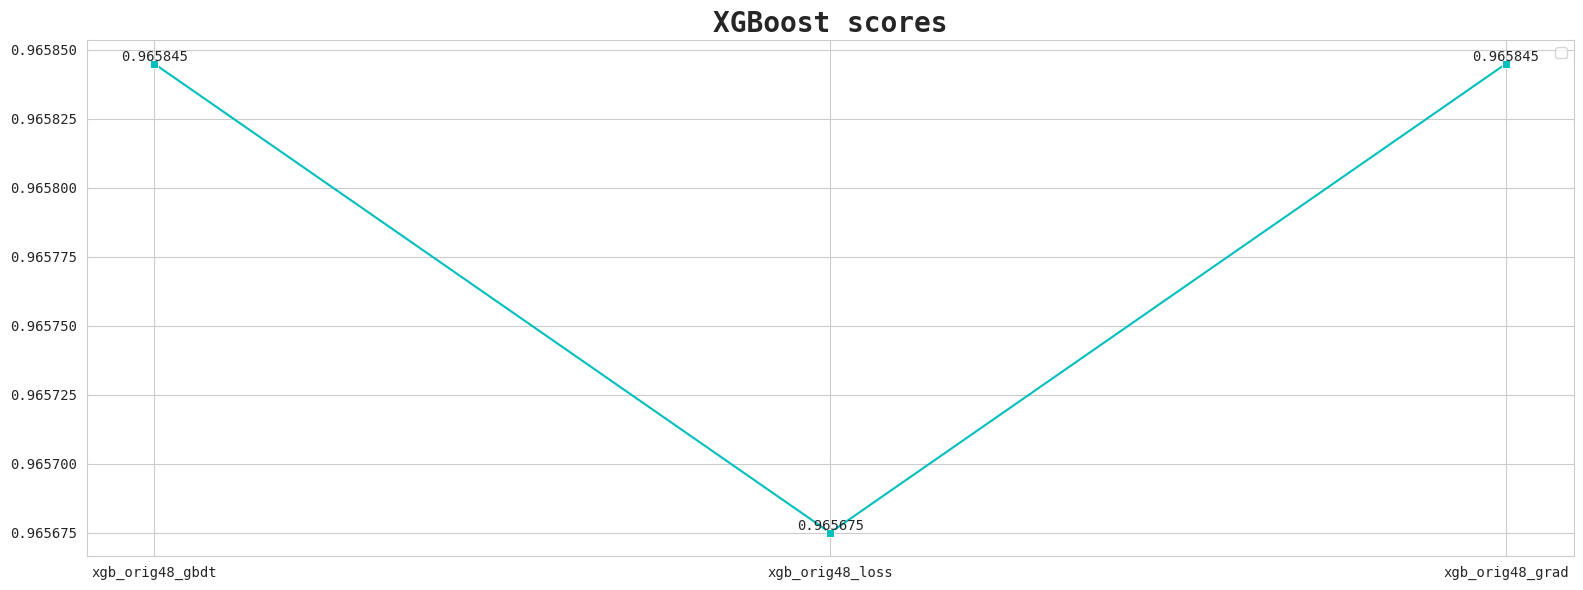

In [38]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

y_add = 1e-6

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# plt.ylim((0.94, 0.955))
plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("XGBoost scores", fontdict={"weight": "semibold", "size": 20})

plt.tight_layout() 
plt.show()

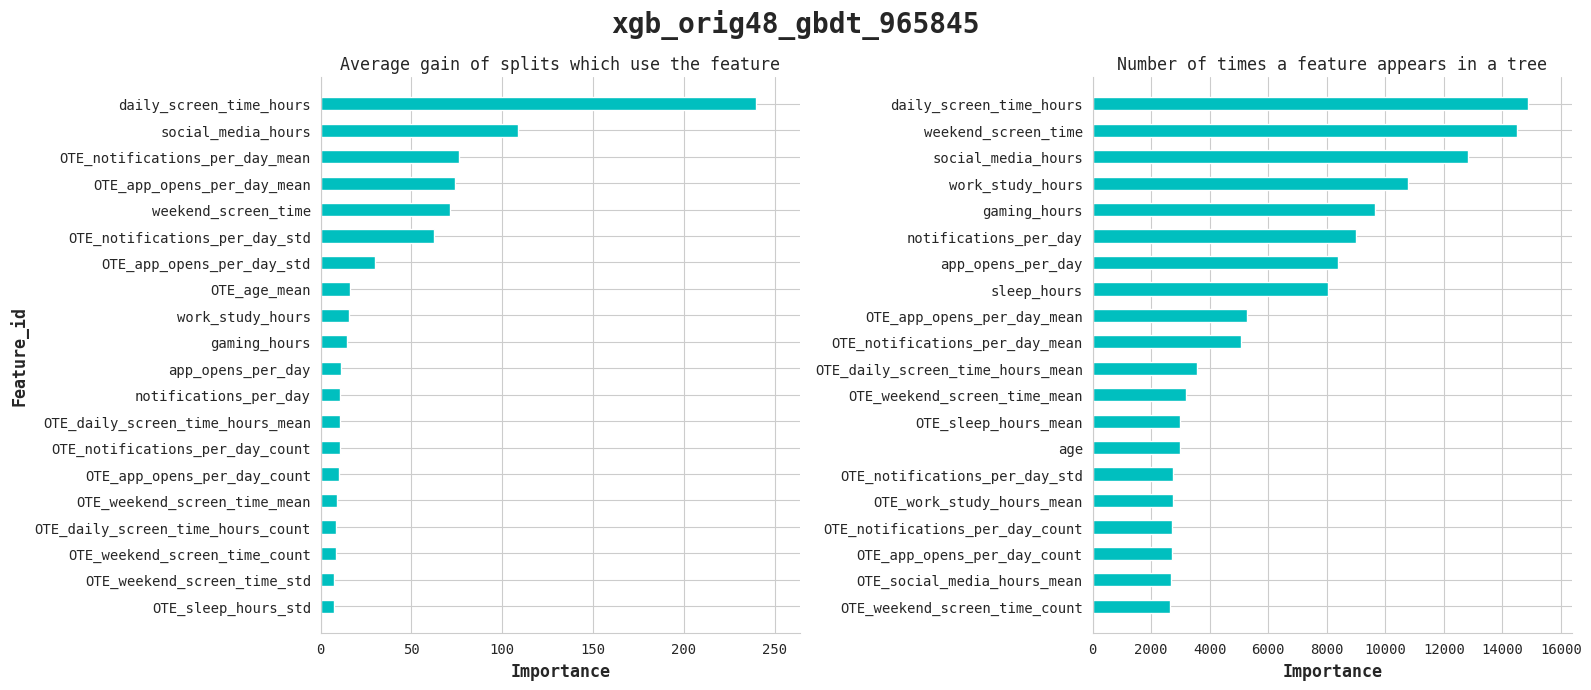

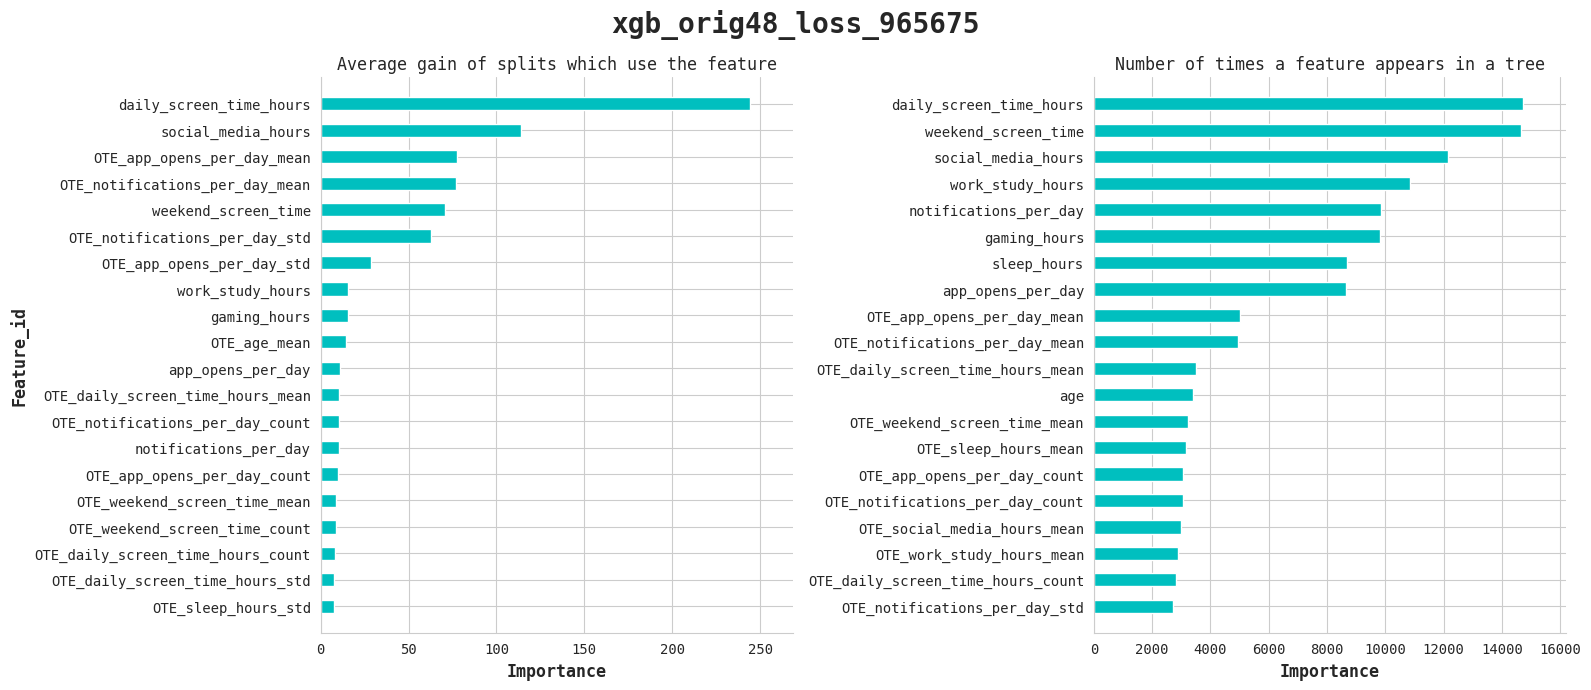

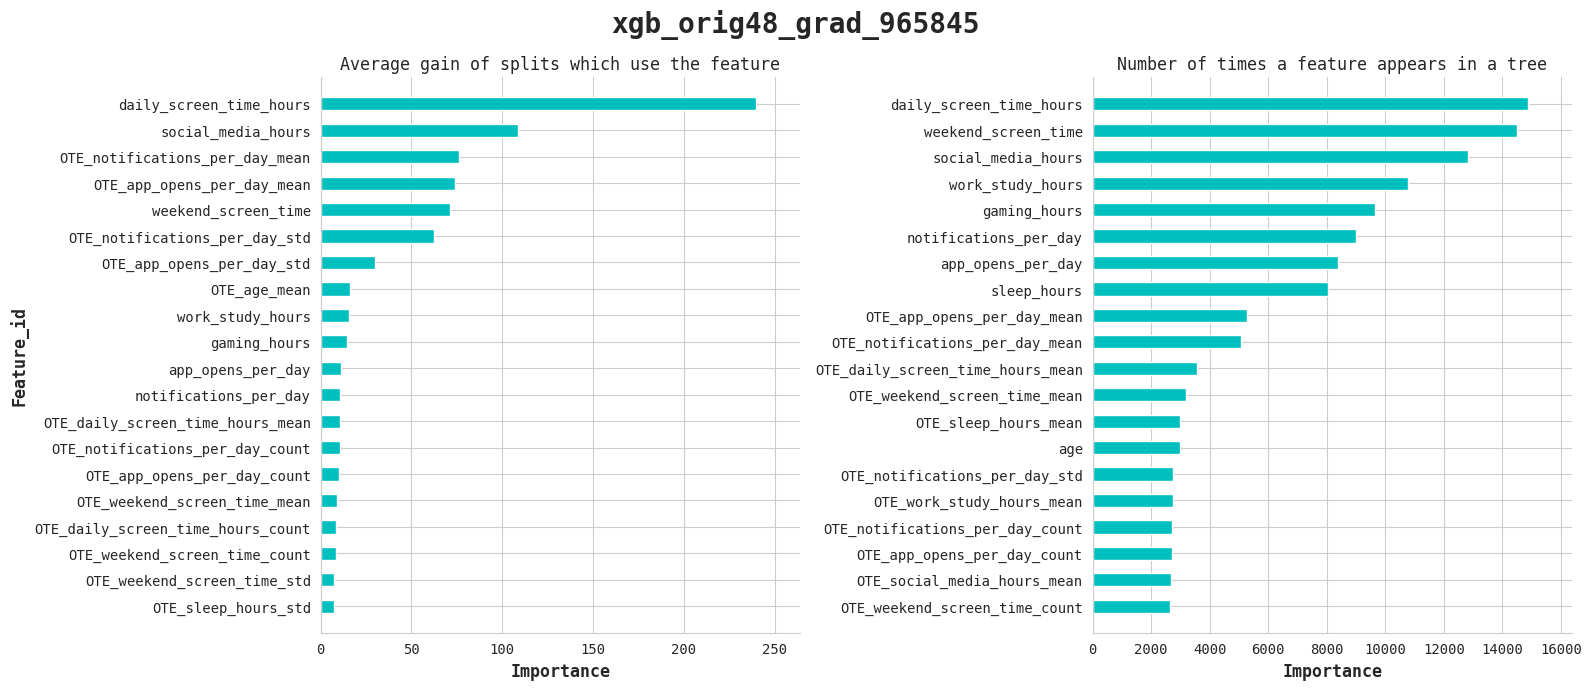

In [39]:
plot_feature_importances(max_cols=20)

xgb_orig48_gbdt_965845 saved!


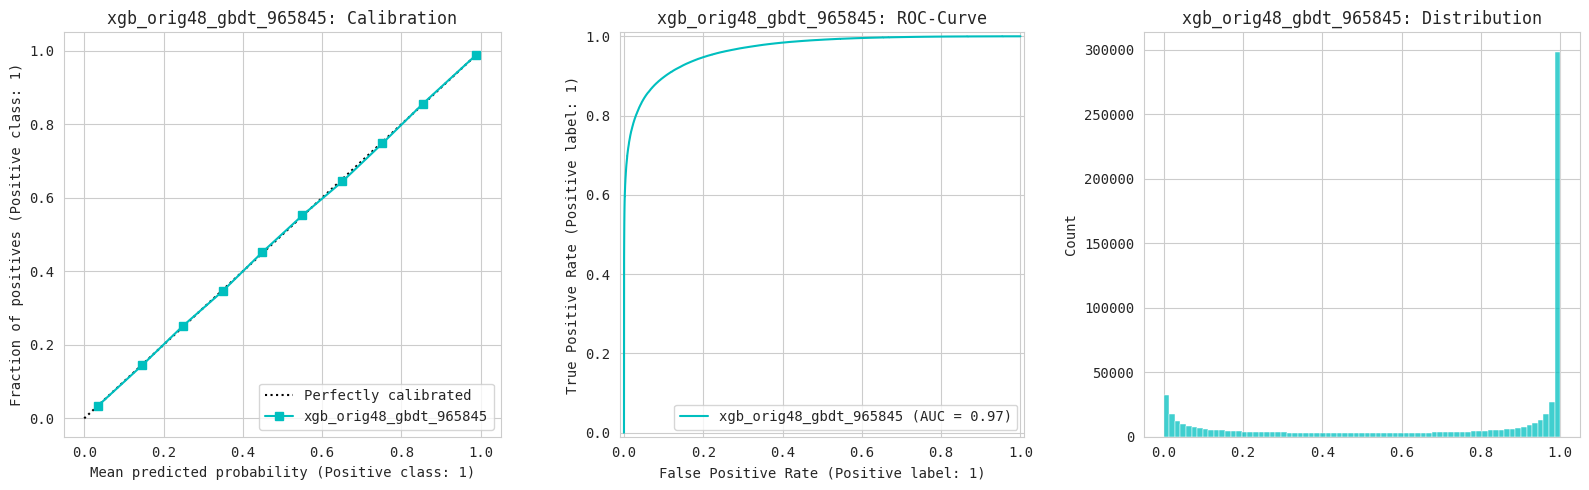


xgb_orig48_loss_965675 saved!


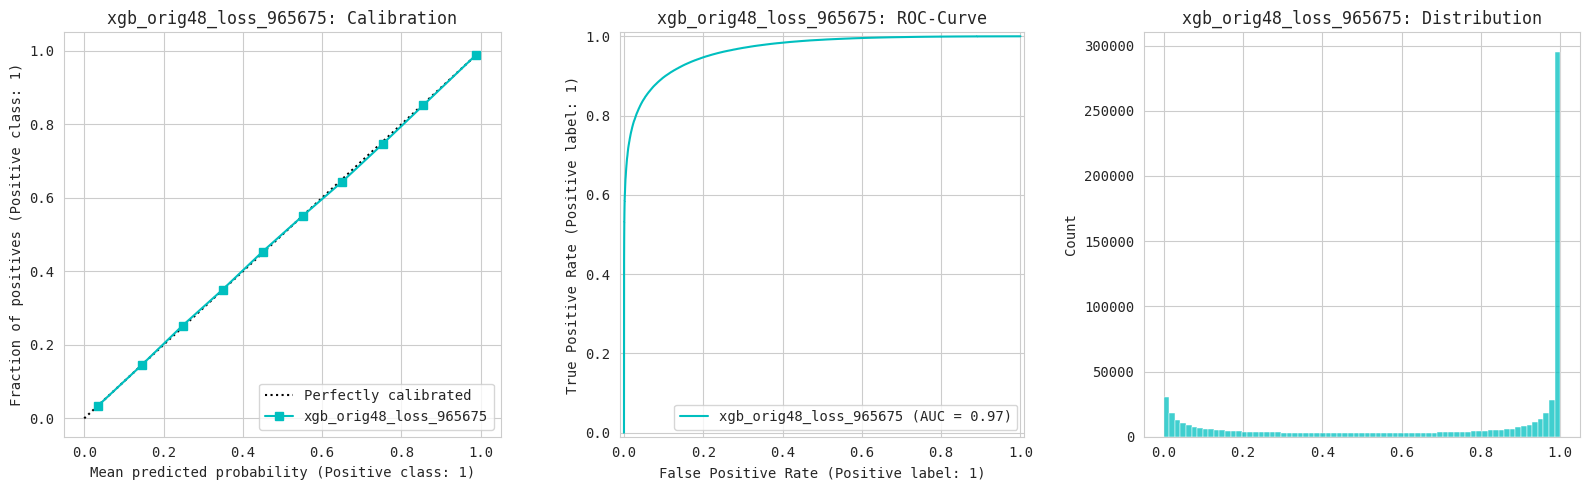


xgb_orig48_grad_965845 saved!


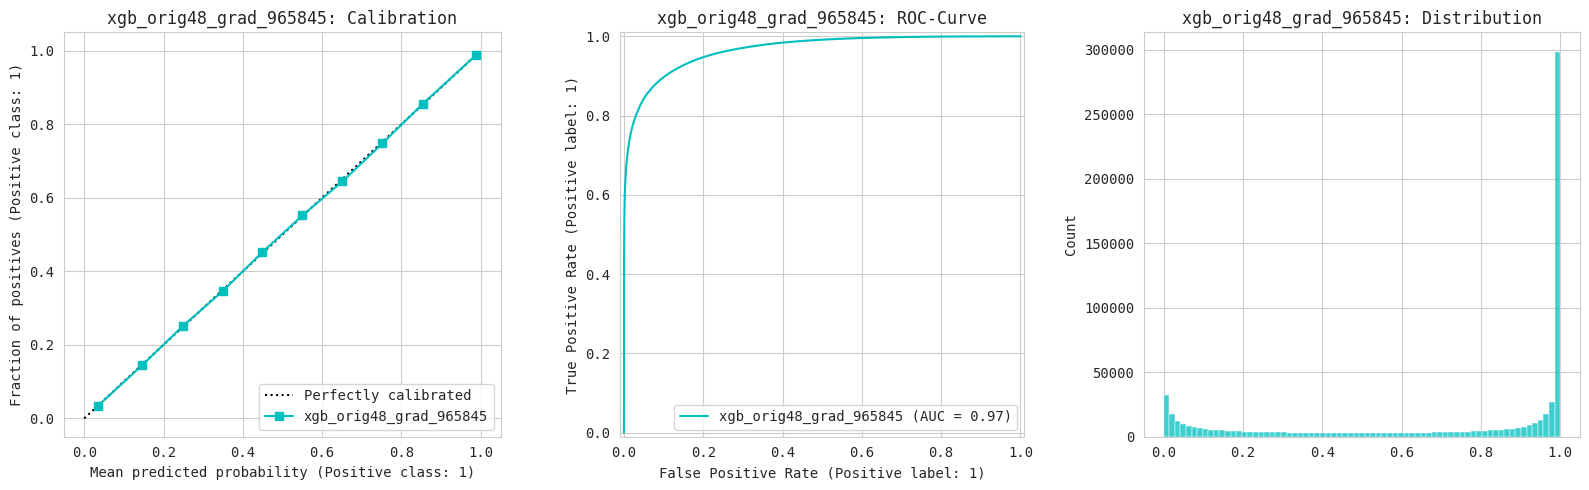

In [40]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [41]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

xgb_orig48_gbdt_965845 saved! (296302,)
xgb_orig48_loss_965675 saved! (296302,)
xgb_orig48_grad_965845 saved! (296302,)


In [42]:
pd.DataFrame(model_results)

,xgb_orig48_gbdt_965845,xgb_orig48_loss_965675,xgb_orig48_grad_965845
0,0.999541,0.999372,0.999541
1,0.933467,0.949821,0.933467
2,0.867866,0.884551,0.867866
3,0.992718,0.992809,0.992718
4,0.996999,0.996484,0.996999
...,...,...,...
296297,0.999999,0.999998,0.999999
296298,0.778316,0.856254,0.778316
296299,0.161080,0.170630,0.161080
296300,0.753222,0.809065,0.753222


In [43]:
# !rm -r /kaggle/working